In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("sales_cleaned.csv")

df['Inv.Date'] = pd.to_datetime(df['Inv.Date'])

df.head()

,Customer Name,Customer Code,Ship To Cust Code,Ship To Cust Name,Bill Type,C,Inv.No,ODN,BUS. PLACE,SO.No,Date,Week,Incoterms,PO.No,PI.No,Cust.Nature,Territory Code,Territory,Inv.Date,Brand,Sub-Brand,Prime Brand,Folder/Non-Folder,Material,Material Desc.,Division,Division Text,Thickness,Vol.CBM,Design(LAM),Finish(LAM),Billed Qty,Sales unit,Billed Qty(SQM),Billed Qty(PCS),Billed Qty(NA),Billed Qty (CBM),Billed Qty (MT),Year,Month,Month_Name,Quarter,Day,Day_Name,Year_Month
0,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI055PC18300305O,5.5 MM CEN PLN MDF- DI-E2 C-1.83 X0.305,22,MDF - Plain,5.50,2.533,NaN,NaN,825,PC,460.515,825,0,2.533,2.003,2021,1,January,1,1,Friday,2021-01
1,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI070PC18300305O,7 MM CEN PLN MDF- DI-E2 C-1.83 X0.305,22,MDF - Plain,7.00,4.419,NaN,NaN,1131,PC,631.324,1131,0,4.419,3.491,2021,1,January,1,1,Friday,2021-01
2,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI110PC19830610O,11 MM CEN PLN MDF-DI-E2 C-1.983X0.61,22,MDF - Plain,11.00,8.116,NaN,NaN,610,PC,737.856,610,0,8.116,0.000,2021,1,January,1,1,Friday,2021-01
3,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI168PC18300610O,16.75 MM CEN PLN MDF- DI-E2 C-1.83 X0.61,22,MDF - Plain,16.75,6.675,NaN,NaN,357,PC,398.519,357,0,6.675,5.272,2021,1,January,1,1,Friday,2021-01
4,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI168PC18300305O,16.75 MM CEN PLN MDF-DI-E2 C-1.83 X0.305,22,MDF - Plain,16.75,0.654,NaN,NaN,70,PC,39.074,70,0,0.654,0.517,2021,1,January,1,1,Friday,2021-01


In [3]:
monthly_demand = (
    df.groupby('Year_Month')['Billed Qty (CBM)']
      .sum()
      .reset_index()
)

monthly_demand

,Year_Month,Billed Qty (CBM)
0,2021-01,14898.690
1,2021-02,14174.106
2,2021-03,16677.113
3,2021-04,12617.536
4,2021-05,8130.638
5,2021-06,11017.353
6,2021-07,11908.396
7,2021-08,13785.516
8,2021-09,16253.704
9,2021-10,19481.490


In [4]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.1 MB 8.4 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.1 MB 12.2 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.1 MB 14.5 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 15.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 26.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
forecast_df = monthly_demand.copy()

forecast_df.columns = ['ds', 'y']

forecast_df['ds'] = pd.to_datetime(
    forecast_df['ds']
)

forecast_df.head()

,ds,y
0,2021-01-01,14898.690
1,2021-02-01,14174.106
2,2021-03-01,16677.113
3,2021-04-01,12617.536
4,2021-05-01,8130.638


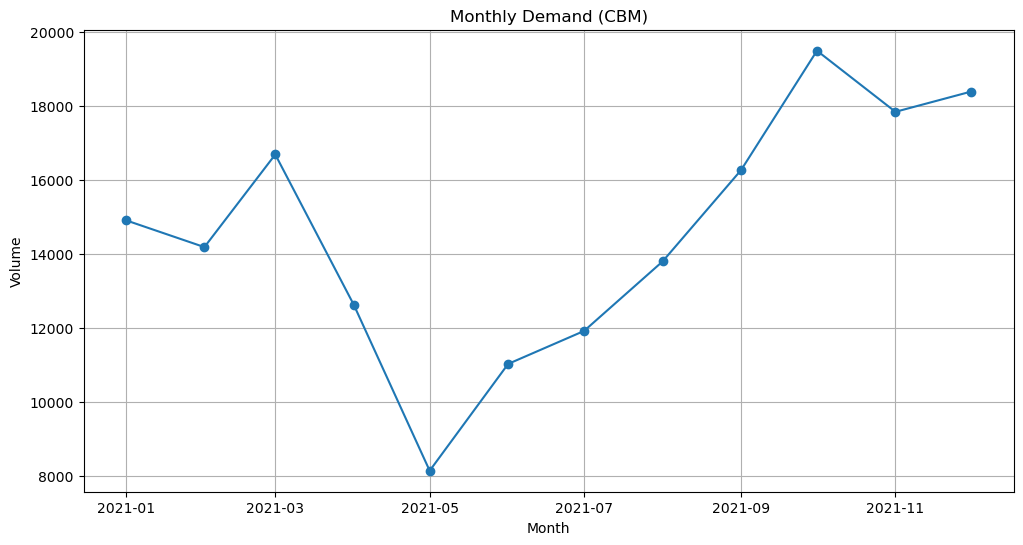

In [6]:
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df['ds'],
    forecast_df['y'],
    marker='o'
)

plt.title("Monthly Demand (CBM)")
plt.xlabel("Month")
plt.ylabel("Volume")

plt.grid(True)

plt.show()

In [7]:
print(forecast_df)

           ds          y
0  2021-01-01  14898.690
1  2021-02-01  14174.106
2  2021-03-01  16677.113
3  2021-04-01  12617.536
4  2021-05-01   8130.638
5  2021-06-01  11017.353
6  2021-07-01  11908.396
7  2021-08-01  13785.516
8  2021-09-01  16253.704
9  2021-10-01  19481.490
10 2021-11-01  17830.418
11 2021-12-01  18379.195


In [8]:
daily_demand = (
    df.groupby('Inv.Date')['Billed Qty (CBM)']
      .sum()
      .reset_index()
)

In [9]:
daily_demand = (
    df.groupby('Inv.Date')['Billed Qty (CBM)']
      .sum()
      .reset_index()
)

daily_demand.columns = ['Date', 'Demand']

daily_demand.head()

,Date,Demand
0,2021-01-01,240.529
1,2021-01-02,470.123
2,2021-01-03,476.100
3,2021-01-04,530.366
4,2021-01-05,597.505


In [10]:
print(daily_demand.shape)

(359, 2)


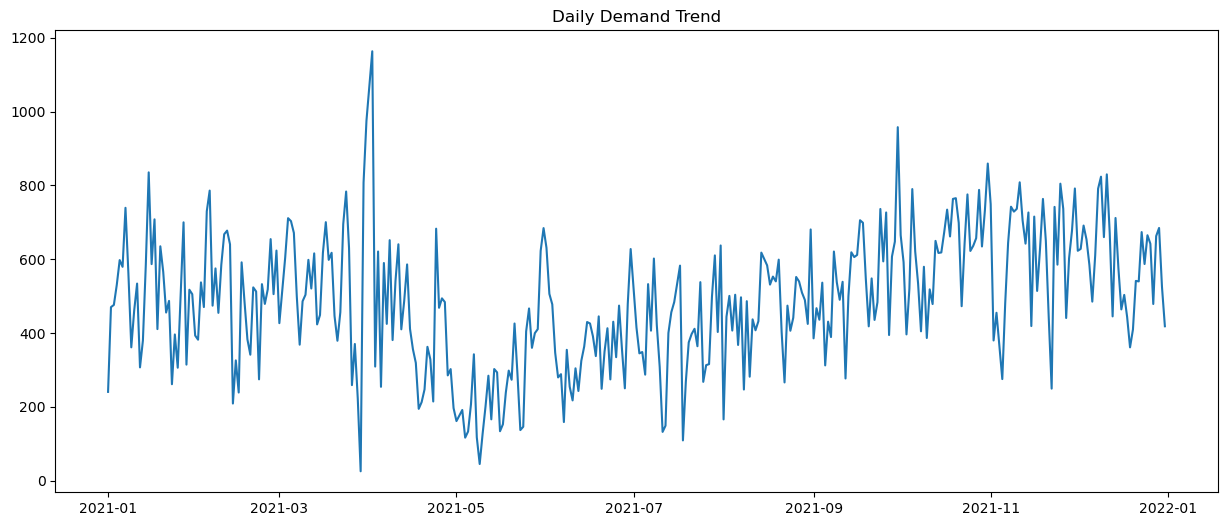

In [11]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_demand['Date'],
    daily_demand['Demand']
)

plt.title('Daily Demand Trend')

plt.show()

# ==========================================
# TRAIN TEST SPLIT
# ==========================================


In [12]:

train_size = int(len(daily_demand) * 0.8)

train = daily_demand[:train_size]
test = daily_demand[train_size:]

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Train Shape: (287, 2)
Test Shape : (72, 2)


# ==========================================
# MOVING AVERAGE FORECAST
# ==========================================


In [13]:
window = 7

moving_avg_predictions = []

history = list(train['Demand'])

for t in range(len(test)):

    prediction = np.mean(history[-window:])

    moving_avg_predictions.append(prediction)

    history.append(test['Demand'].iloc[t])

In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    test['Demand'],
    moving_avg_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test['Demand'],
        moving_avg_predictions
    )
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

MAE : 120.02
RMSE: 149.06


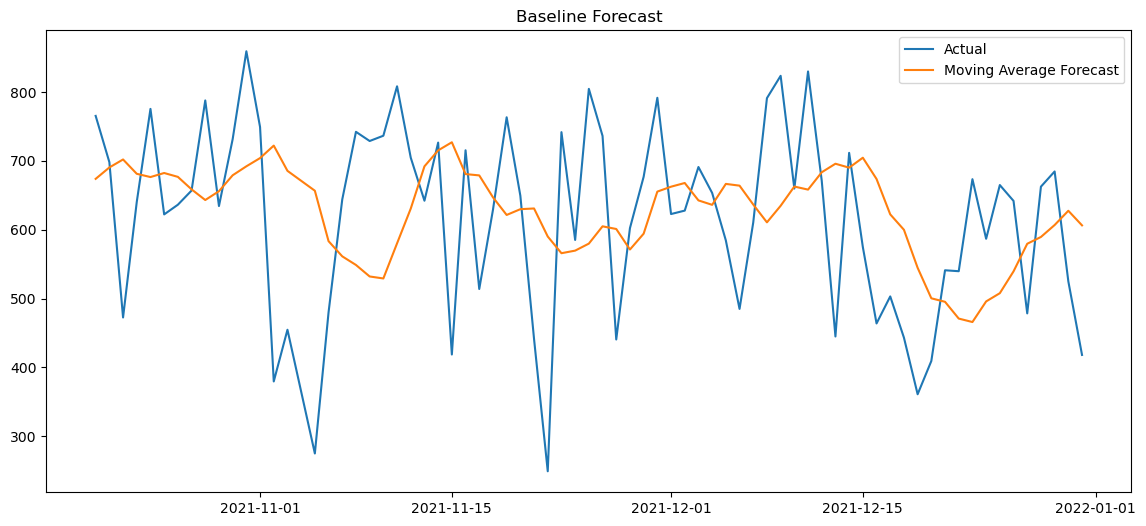

In [15]:
plt.figure(figsize=(14,6))

plt.plot(
    test['Date'],
    test['Demand'],
    label='Actual'
)

plt.plot(
    test['Date'],
    moving_avg_predictions,
    label='Moving Average Forecast'
)

plt.title('Baseline Forecast')

plt.legend()

plt.show()

In [22]:
import statsmodels

In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [24]:
train_size = int(len(daily_demand) * 0.8)

train = daily_demand[:train_size]
test = daily_demand[train_size:]

In [25]:
model = ExponentialSmoothing(
    train['Demand'],
    trend='add',
    seasonal=None
)

fit_model = model.fit()

In [26]:
predictions = fit_model.forecast(
    len(test)
)

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    test['Demand'],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test['Demand'],
        predictions
    )
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

MAE : 200.76
RMSE: 251.62


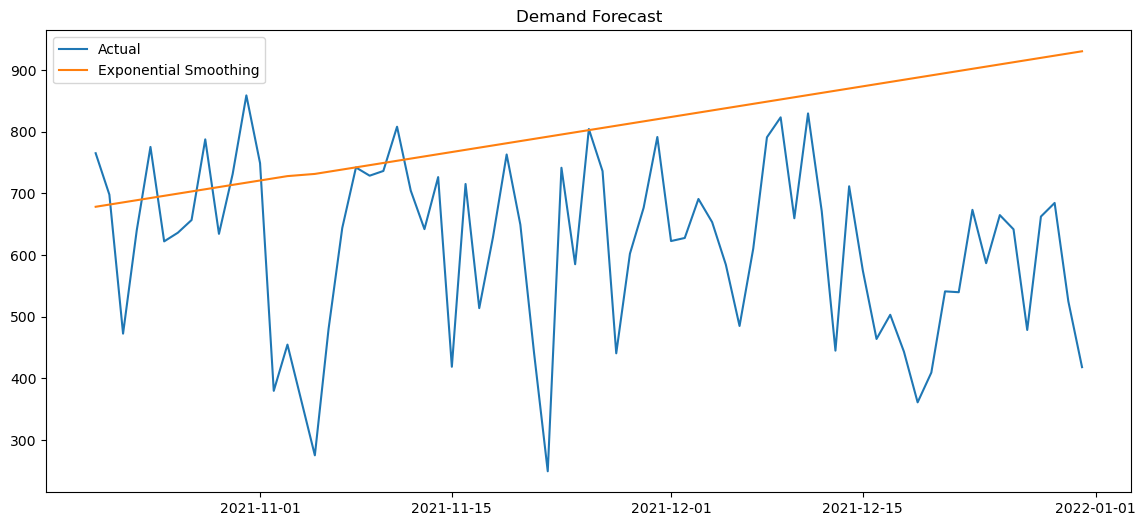

In [28]:
plt.figure(figsize=(14,6))

plt.plot(
    test['Date'],
    test['Demand'],
    label='Actual'
)

plt.plot(
    test['Date'],
    predictions,
    label='Exponential Smoothing'
)

plt.title('Demand Forecast')

plt.legend()

plt.show()